# 현지실사 예측 모형

## 1. Feature Selection
### 1.1 특정 알고리즘을 바탕으로 몇 개의 feature를 추출할 것인지 simulation
### 1.2 Tuning wuth CV을 하면서 몇 개의 feature를 추출할 것인지 simulation

## 2. Two Tuning strategies
### 1.1 예측성능지표(복수)로 refit을 사용하여 최적화 튜닝
- Demonstration of multi-metric evaluation on cross_val_score and GridSearchCV(사이킷런 예제)
### 1.2 실제 운영기준(정밀검사 대상 개수 선정)으로 Decision threshold를 선정하는 방법
<img src = 'https://images.unsplash.com/photo-1579566346927-c68383817a25?ixlib=rb-1.2.1&ixid=MnwxMjA3fDB8MHxzZWFyY2h8MTh8fHN0YXIlMjB3YXJzfGVufDB8fDB8fA%3D%3D&auto=format&fit=crop&w=500&q=60'>

In [30]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
import warnings
warnings.filterwarnings(action='ignore')
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
get_ipython().run_line_magic('matplotlib', 'inline')
plt.rcParams['font.family']='Malgun Gothic' # 한글폰트
plt.rcParams['axes.unicode_minus'] = False
#pd.read_pickle(path + '/data_01_대장.pkl').to_excel(path + '/data_01_대장.xlsx')

In [9]:
def summary(df) :
    tf = pd.DataFrame({'데이터형태(dtypes)' : df.dtypes,
                       '결측치 수(null)' : df.isnull().sum(),
                       '결측치 비율(%)' : (df.isnull().sum()/len(df)).round(2),
                       '고유값 수(nunique)' : df.nunique(),
                      })
    for col in tf.index:
        tf.loc[col, '자료 내용(contents)'] = str(df[col].unique()[0:5])
        #tf.loc[col, 'False 비율']  =  df[col].value_counts(normalize=True).loc[1]
        
    return tf

In [13]:
data = pd.read_pickle(path + '/data_01_대장.pkl').set_index('해외제조업소_코드')
data.columns = ['A02_국가코드', '업소명', '대표자성명', '주소', '전화번호', '이메일', '회사이메일', '팩스', '인증',
       '공식인증', '수산물', '등록', '수입거부', '수입중단', '등록취소', 'target']
data.head()

,A02_국가코드,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,등록,수입거부,수입중단,등록취소,target
해외제조업소_코드,,,,,,,,,,,,,,,,
CN000095375,CN,True,True,True,True,True,False,False,False,False,False,True,False,False,False,False
CN000010833,CN,True,True,True,True,True,False,False,False,False,False,True,False,False,False,False
VN000000420,VN,True,True,True,True,True,True,True,False,False,False,True,False,False,False,False
JP000002818,JP,True,True,True,True,True,True,False,False,False,False,True,False,False,False,False
TH000001271,TH,True,True,True,True,True,False,True,True,True,False,False,False,False,True,False


In [14]:
summary(data)

,데이터형태(dtypes),결측치 수(null),결측치 비율(%),고유값 수(nunique),자료 내용(contents)
A02_국가코드,object,0,0.0,45,['CN' 'VN' 'JP' 'TH' 'ID']
업소명,bool,0,0.0,1,[ True]
대표자성명,bool,0,0.0,2,[ True False]
주소,bool,0,0.0,2,[ True False]
전화번호,bool,0,0.0,2,[ True False]
이메일,bool,0,0.0,2,[ True False]
회사이메일,bool,0,0.0,2,[False True]
팩스,bool,0,0.0,2,[False True]
인증,bool,0,0.0,2,[False True]
공식인증,bool,0,0.0,2,[False True]


In [15]:
from sklearn.feature_selection import chi2, SelectKBest

import category_encoders as ce
woe = ce.woe.WOEEncoder()
cat = ce.cat_boost.CatBoostEncoder()
tm = ce.target_encoder.TargetEncoder()
data['A02_국가코드'] = tm.fit_transform(data['A02_국가코드'], data.target)

In [16]:
X = data.iloc[:, :-1]
X.shape
y = data.target

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size = 0.2, random_state=12)

(1689, 15)

0.9171597633136095

              precision    recall  f1-score   support

       False       0.93      0.97      0.95       279
        True       0.82      0.68      0.74        59

    accuracy                           0.92       338
   macro avg       0.88      0.82      0.85       338
weighted avg       0.91      0.92      0.91       338



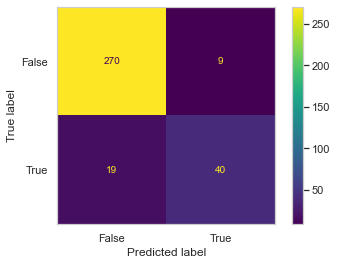

In [17]:
from sklearn import ensemble 
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score
# 성능지표
from sklearn.metrics import accuracy_score, plot_roc_curve 
from sklearn.metrics import plot_confusion_matrix, classification_report
# 파이프라인
from sklearn.pipeline import Pipeline, make_pipeline
# 시각화 툴
import scikitplot as skplt
rf = ensemble.RandomForestClassifier(random_state=11)
#rf = ensemble.RandomForestClassifier(random_state=11, class_weight='balanced') # data.drop(['업소명','등록', '수입거부', '수입중단', '등록취소'], axis=1, inplace=True)
y_predict = rf.fit(X_train, y_train).predict(X_test)
accuracy_score(y_test, y_predict)
print(classification_report(y_test, y_predict))
sns.set_style("whitegrid", {'axes.grid' : False})
plot_confusion_matrix(rf, X_test, y_test)

# 1. ExhaustiveFeatureSelector: Optimal feature sets by considering all possible feature combinations
- http://rasbt.github.io/mlxtend/user_guide/feature_selection/ExhaustiveFeatureSelector/#exhaustivefeatureselector-optimal-feature-sets-by-considering-all-possible-feature-combinations

### A simple one

In [31]:
from sklearn.neighbors import KNeighborsClassifier
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS

start = time.time()  # 시작 시간 저장

knn = KNeighborsClassifier(n_neighbors=3)

efs1 = EFS(knn, 
           min_features=1,
           max_features=4,
           scoring='accuracy',
           print_progress=True,
           cv=5)

efs1 = efs1.fit(X_train, y_train)

print('Best accuracy score: %.2f' % efs1.best_score_)
print('Best subset (indices):', efs1.best_idx_)
print('Best subset (corresponding names):', efs1.best_feature_names_)

print("프로그램을 수행하는데 걸린 시간(초) :", time.time() - start)  # 현재시각 - 시작시간 = 실행 시간

Features: 1940/1940

Best accuracy score: 0.92
Best subset (indices): (2, 10, 11)
Best subset (corresponding names): ('대표자성명', '수산물', '등록')
프로그램을 수행하는데 걸린 시간(초) : 84.98071432113647


###  Exhaustive feature selection and GridSearch

In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression


lr = LogisticRegression(solver='newton-cg', 
                        random_state=123)

efs1 = EFS(estimator=lr, 
           min_features=2,
           max_features=4,
           scoring='accuracy',
           print_progress=False,
           clone_estimator=False,
           cv=5,
           n_jobs=1)

pipe = make_pipeline(efs1, lr)

param_grid = {'exhaustivefeatureselector__estimator__C': [0.1, 1.0, 10.0]}

start = time.time()  # 시작 시간 저장

gs = GridSearchCV(estimator=pipe, 
                  param_grid=param_grid, 
                  scoring='accuracy', 
                  n_jobs=1, 
                  cv=2, 
                  verbose=1, 
                  refit=False)

# run gridearch
gs = gs.fit(X_train, y_train)

print("프로그램을 수행하는데 걸린 시간(초) :", time.time() - start)  # 현재시각 - 시작시간 = 실행 시간

Fitting 2 folds for each of 3 candidates, totalling 6 fits
프로그램을 수행하는데 걸린 시간(초) : 248.4753293991089


In [36]:
print("Best parameters via GridSearch", gs.best_params_)

Best parameters via GridSearch {'exhaustivefeatureselector__estimator__C': 1.0}


In [38]:
gs.estimator.steps

[('exhaustivefeatureselector',
  ExhaustiveFeatureSelector(clone_estimator=False,
                            estimator=LogisticRegression(random_state=123,
                                                         solver='newton-cg'),
                            max_features=4, min_features=2, print_progress=False)),
 ('logisticregression',
  LogisticRegression(random_state=123, solver='newton-cg'))]

# 2. Fine tuning a classifier in scikit-learn
- https://towardsdatascience.com/fine-tuning-a-classifier-in-scikit-learn-66e048c21e65

### Strategy 1 : Optimize for sensitivity using GridSearchCV with the scoring argument.

In [42]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_curve, precision_recall_curve, auc, make_scorer, recall_score, accuracy_score, precision_score, confusion_matrix

### The scoring parameter: defining model evaluation rules

- 복수의 성과지표로 CV과 Hyper 파라미터 튜닝 방법
- 재현율이나 정밀도는 threshold를 0.5를 기준으로 튜닝하지만 average_precision_score은 threshold를 모두 고려
- https://scikit-learn.org/stable/modules/model_evaluation.html#the-scoring-parameter-defining-model-evaluation-rules

In [78]:
from sklearn import metrics

In [79]:
clf = ensemble.RandomForestClassifier(n_jobs=-1)

param_grid = {
    'min_samples_split': [3, 5, 10], 
    'n_estimators' : [100, 300],
    'max_depth': [3, 5, 15, 25],
    'max_features': [3, 5, 10, 20]
}
# 복수의 성과지표 재현율이나 정밀도는 threshold를 0.5를 기준으로 튜닝하지만 average_precision_score은 threshold를 모두 고려
scorers = {
    'precision_score': make_scorer(precision_score),
    'recall_score': make_scorer(recall_score),
    'f1_score': make_scorer(metrics.f1_score),
    'roc_auc_score': make_scorer(roc_auc_score),
    'average_precision_score': make_scorer(average_precision_score),
}

In [80]:
def grid_search_wrapper(refit_score='precision_score'):
    """
    fits a GridSearchCV classifier using refit_score for optimization
    prints classifier performance metrics
    """
    skf = StratifiedKFold(n_splits=5)
    
    grid_search = GridSearchCV(clf, param_grid, scoring=scorers, 
                               refit=refit_score,
                               cv=skf, 
                               return_train_score=True, n_jobs=-1)
    
    grid_search.fit(X_train.values, y_train.values)

    # make the predictions
    y_pred = grid_search.predict(X_test.values)

    print('Best params for {}'.format(refit_score))
    print(grid_search.best_params_)

    # confusion matrix on the test data.
    print('\nConfusion matrix of Random Forest optimized for {} on the test data:'.format(refit_score))
    print(pd.DataFrame(confusion_matrix(y_test, y_pred),
                 columns=['pred_neg', 'pred_pos'], index=['neg', 'pos']))
    return grid_search

In [81]:
grid_search_clf = grid_search_wrapper(refit_score='precision_score')

Best params for precision_score
{'max_depth': 3, 'max_features': 3, 'min_samples_split': 3, 'n_estimators': 100}

Confusion matrix of Random Forest optimized for precision_score on the test data:
     pred_neg  pred_pos
neg       271         8
pos        20        39


In [84]:
results = pd.DataFrame(grid_search_clf.cv_results_)
results = results.sort_values(by='mean_test_precision_score', ascending=False)
results[['mean_test_precision_score', 'mean_test_recall_score', 'mean_test_f1_score', 'mean_test_roc_auc_score', 'mean_test_average_precision_score', 'param_max_depth', 'param_max_features', 'param_min_samples_split', 'param_n_estimators']].round(3).head()

,mean_test_precision_score,mean_test_recall_score,mean_test_f1_score,mean_test_roc_auc_score,mean_test_average_precision_score,param_max_depth,param_max_features,param_min_samples_split,param_n_estimators
0,0.917,0.504,0.642,0.746,0.540,3,3,3,100
1,0.870,0.518,0.645,0.750,0.528,3,3,3,300
47,0.861,0.604,0.708,0.792,0.586,5,20,10,300
36,0.861,0.599,0.705,0.790,0.582,5,10,3,100
38,0.861,0.599,0.705,0.790,0.582,5,10,5,100


In [85]:
scorers

{'precision_score': make_scorer(precision_score),
 'recall_score': make_scorer(recall_score),
 'f1_score': make_scorer(f1_score),
 'roc_auc_score': make_scorer(roc_auc_score),
 'average_precision_score': make_scorer(average_precision_score)}

In [88]:
from tqdm import tqdm
for score , _ in tqdm(scorers.items()):
    grid_search_clf = grid_search_wrapper(refit_score= score)
    print('*'*100)

 20%|████████████████▊                                                                   | 1/5 [00:33<02:12, 33.21s/it]

Best params for precision_score
{'max_depth': 3, 'max_features': 3, 'min_samples_split': 3, 'n_estimators': 300}

Confusion matrix of Random Forest optimized for precision_score on the test data:
     pred_neg  pred_pos
neg       272         7
pos        20        39
****************************************************************************************************


 40%|█████████████████████████████████▌                                                  | 2/5 [01:06<01:39, 33.29s/it]

Best params for recall_score
{'max_depth': 3, 'max_features': 5, 'min_samples_split': 3, 'n_estimators': 100}

Confusion matrix of Random Forest optimized for recall_score on the test data:
     pred_neg  pred_pos
neg       269        10
pos        18        41
****************************************************************************************************


 60%|██████████████████████████████████████████████████▍                                 | 3/5 [01:38<01:05, 32.73s/it]

Best params for f1_score
{'max_depth': 5, 'max_features': 20, 'min_samples_split': 5, 'n_estimators': 100}

Confusion matrix of Random Forest optimized for f1_score on the test data:
     pred_neg  pred_pos
neg       271         8
pos        19        40
****************************************************************************************************


 80%|███████████████████████████████████████████████████████████████████▏                | 4/5 [02:10<00:32, 32.48s/it]

Best params for roc_auc_score
{'max_depth': 3, 'max_features': 10, 'min_samples_split': 3, 'n_estimators': 100}

Confusion matrix of Random Forest optimized for roc_auc_score on the test data:
     pred_neg  pred_pos
neg       269        10
pos        18        41
****************************************************************************************************


100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [02:44<00:00, 32.83s/it]

Best params for average_precision_score
{'max_depth': 5, 'max_features': 20, 'min_samples_split': 10, 'n_estimators': 100}

Confusion matrix of Random Forest optimized for average_precision_score on the test data:
     pred_neg  pred_pos
neg       271         8
pos        19        40
****************************************************************************************************


In [49]:
grid_search_clf = grid_search_wrapper(refit_score='recall_score')

Best params for recall_score
{'max_depth': 3, 'max_features': 5, 'min_samples_split': 10, 'n_estimators': 300}

Confusion matrix of Random Forest optimized for recall_score on the test data:
     pred_neg  pred_pos
neg       269        10
pos        18        41


In [51]:
results = pd.DataFrame(grid_search_clf.cv_results_)
results = results.sort_values(by='mean_test_average_precision_score', ascending=False)
results[['mean_test_precision_score', 'mean_test_recall_score', 'mean_test_f1_score', 'mean_test_roc_auc_score', 'mean_test_average_precision_score', 'param_max_depth', 'param_max_features', 'param_min_samples_split', 'param_n_estimators']].round(3)

,mean_test_precision_score,mean_test_recall_score,mean_test_accuracy_score,param_max_depth,param_max_features,param_min_samples_split,param_n_estimators
0,0.893,0.559,0.915,3,3,3,100
1,0.877,0.536,0.910,3,3,3,300
34,0.867,0.586,0.916,5,5,10,100
2,0.866,0.546,0.910,3,3,5,100
5,0.864,0.518,0.906,3,3,10,300


### Demonstration of multi-metric evaluation on cross_val_score and GridSearchCV
- https://scikit-learn.org/stable/auto_examples/model_selection/plot_multi_metric_evaluation.html
<img src ='https://scikit-learn.org/stable/_images/sphx_glr_plot_multi_metric_evaluation_001.png' width=800 height=800>

### Strategy 2: Adjust the decision threshold to identify the operating point

In [53]:
y_scores = grid_search_clf.predict_proba(X_test)[:, 1]
p, r, thresholds = precision_recall_curve(y_test, y_scores)

In [66]:
def adjusted_classes(y_scores, t):
    """
    This function adjusts class predictions based on the prediction threshold (t).
    Will only work for binary classification problems.
    """
    return [1 if y >= t else 0 for y in y_scores]

def precision_recall_threshold(p, r, thresholds, t=0.5):
    """
    plots the precision recall curve and shows the current value for each
    by identifying the classifier's threshold (t).
    """
    
    # generate new class predictions based on the adjusted_classes
    # function above and view the resulting confusion matrix.
    y_pred_adj = adjusted_classes(y_scores, t)
    print(pd.DataFrame(confusion_matrix(y_test, y_pred_adj),
                       columns=['pred_neg', 'pred_pos'], 
                       index=['neg', 'pos']))
    
    # plot the curve
    plt.figure(figsize=(8,6))
    plt.title("Precision and Recall curve ^ = current threshold")
    plt.step(r, p, color='b', alpha=0.2,
             where='post')
    plt.fill_between(r, p, step='post', alpha=0.2,
                     color='b')
    plt.ylim([0.5, 1.01]);
    plt.xlim([0.5, 1.01]);
    plt.xlabel('Recall');
    plt.ylabel('Precision');
    
    # plot the current threshold on the line
    close_default_clf = np.argmin(np.abs(thresholds - t))
    plt.plot(r[close_default_clf], p[close_default_clf], '^', c='k',
            markersize=15)

     pred_neg  pred_pos
neg       262        17
pos        17        42


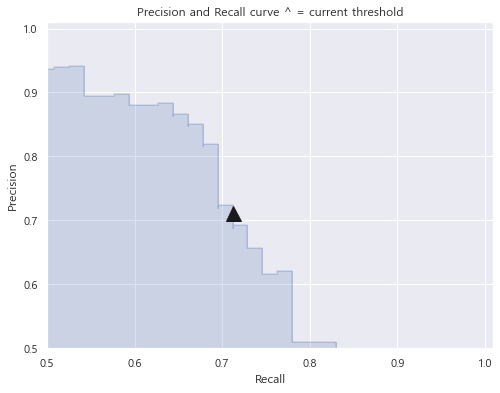

In [67]:
precision_recall_threshold(p, r, thresholds, 0.30)

     pred_neg  pred_pos
neg       269        10
pos        18        41


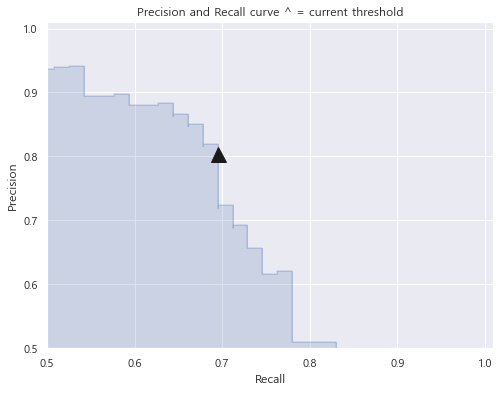

In [68]:
precision_recall_threshold(p, r, thresholds, 0.50)

     pred_neg  pred_pos
neg       262        17
pos        17        42


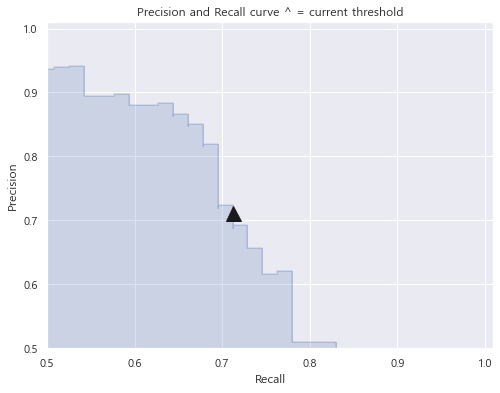

In [69]:
precision_recall_threshold(p, r, thresholds, 0.30)

     pred_neg  pred_pos
neg       274         5
pos        21        38


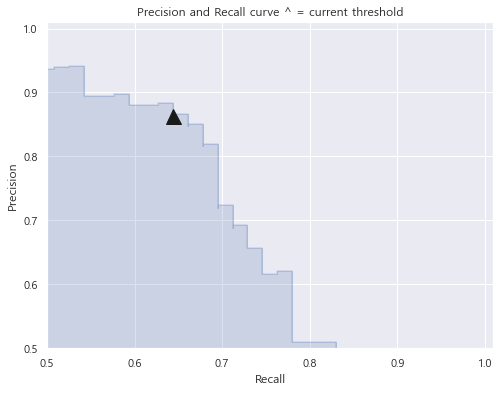

In [70]:
precision_recall_threshold(p, r, thresholds, 0.60)

In [73]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    """
    Modified from:
    Hands-On Machine learning with Scikit-Learn
    and TensorFlow; p.89
    """
    plt.figure(figsize=(8, 6))
    plt.title("Precision and Recall Scores as a function of the decision threshold")
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.ylabel("Score")
    plt.xlabel("Decision Threshold")
    plt.legend(loc='best')

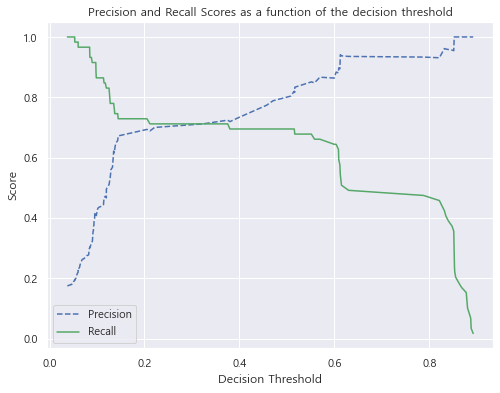

In [74]:
plot_precision_recall_vs_threshold(p, r, thresholds)

# 최재석박사 작업분

In [139]:
path = r'D:\smart food\현지실사\2022_2_현지실사\working_ml'
data = pd.read_pickle(path + '/data_01_대장.pkl').reset_index(drop=True).iloc[:,2:]
data

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,R,S,Y,target
0,True,True,True,True,True,False,False,False,False,False,True,False,False,False,False
1,True,True,True,True,True,False,False,False,False,False,True,False,False,False,False
2,True,True,True,True,True,True,True,False,False,False,True,False,False,False,False
3,True,True,True,True,True,True,False,False,False,False,True,False,False,False,False
4,True,True,True,True,True,False,True,True,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1684,True,True,True,True,True,True,False,True,True,False,True,False,False,False,False
1685,True,True,True,True,True,True,False,True,True,False,True,False,False,False,False
1686,True,True,True,True,True,True,True,True,True,False,True,False,False,False,False
1687,True,True,True,True,True,True,False,True,True,False,True,False,False,False,False


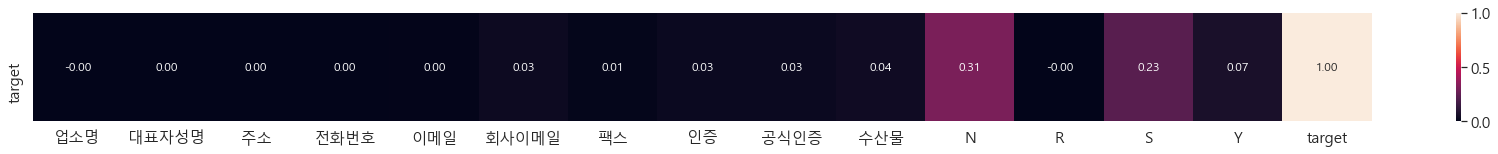

In [31]:
columns = data.columns
theilu = pd.DataFrame(index=['target'], columns= columns)
cat_corr(data)

In [32]:
from sklearn.feature_selection import chi2

In [33]:
X = data.iloc[:, :-1]
y = data.target
chi2_selector = SelectKBest(chi2, k=12)
chi2_selector.fit(X, y)
chi2_scores = pd.DataFrame(list(zip(data.columns, chi2_selector.scores_, chi2_selector.pvalues_)), columns=['컬럼', '카이제곱값', 'p_value'])
chi2_scores.fillna(0).set_index('컬럼').sort_values('카이제곱값')#.plot(kind='bar', rot=360, figsize=(25,5), fontsize=18)

SelectKBest(k=12, score_func=<function chi2 at 0x000001F3AE5A7E50>)

,카이제곱값,p_value
컬럼,,
업소명,0.000000,1.000000e+00
R,0.000000,0.000000e+00
주소,0.023560,8.780106e-01
전화번호,0.094741,7.582347e-01
대표자성명,0.101696,7.498041e-01
이메일,0.116359,7.330179e-01
팩스,6.439360,1.116188e-02
회사이메일,20.763620,5.196070e-06
인증,25.883677,3.626227e-07


In [34]:
best_features =12
def Chi_selector(X, y):
    chi_selector = SelectKBest(chi2, k=best_features)
    chi_selector.fit(X, y)
    chi_support = chi_selector.get_support()
    chi_feature = X.loc[:, chi_support].columns.tolist()
    return chi_feature, chi_support
chi_feature, chi_support = Chi_selector(X, y)
','.join(chi_feature)
chi_support

'대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,S,Y'

array([False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True])

In [35]:
data.corr().fillna(0)

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,R,S,Y,target
업소명,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
대표자성명,0.0,1.000000,0.024290,0.886230,0.853757,0.177161,0.150163,0.113389,0.111984,-0.109535,0.155574,0.0,0.043816,-0.244464,0.049803
주소,0.0,0.024290,1.000000,0.024965,0.022997,0.023902,0.058362,0.062591,0.061697,-0.070858,0.059397,0.0,-0.043935,-0.036775,-0.038373
전화번호,0.0,0.886230,0.024965,1.000000,0.914169,0.198397,0.171169,0.119823,0.118460,-0.103232,0.159128,0.0,0.043265,-0.248601,0.048667
이메일,0.0,0.853757,0.022997,0.914169,1.000000,0.205890,0.154980,0.124349,0.122934,-0.131036,0.148784,0.0,0.044899,-0.236587,0.052019
회사이메일,0.0,0.177161,0.023902,0.198397,0.205890,1.000000,-0.082495,0.265974,0.273270,-0.210535,0.202374,0.0,-0.112798,-0.159697,-0.179560
팩스,0.0,0.150163,0.058362,0.171169,0.154980,-0.082495,1.000000,0.023234,0.023115,0.249913,0.106227,0.0,-0.074694,-0.069388,-0.091747
인증,0.0,0.113389,0.062591,0.119823,0.124349,0.265974,0.023234,1.000000,0.988624,-0.214112,0.241672,0.0,-0.142463,-0.183473,-0.156191
공식인증,0.0,0.111984,0.061697,0.118460,0.122934,0.273270,0.023115,0.988624,1.000000,-0.215180,0.244446,0.0,-0.144583,-0.185128,-0.158318
수산물,0.0,-0.109535,-0.070858,-0.103232,-0.131036,-0.210535,0.249913,-0.214112,-0.215180,1.000000,0.081340,0.0,-0.090737,-0.021860,-0.173017


### 업소명과 R 변수를 제거

In [140]:
data.drop(['업소명','R'], axis=1, inplace=True)
#data.drop(['업소명','N', 'R', 'S', 'Y'], axis=1, inplace=True)
X = data.iloc[:, :-1]
y = data.target

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size = 0.2, random_state=12)

In [151]:
from sklearn.linear_model import LogisticRegression
rf = LogisticRegression(random_state=0)

In [ ]:
from sklearn import ensemble 
rf = ensemble.RandomForestClassifier(random_state=11, class_weight='balanced')

0.9112426035502958

              precision    recall  f1-score   support

       False       0.93      0.96      0.95       279
        True       0.78      0.68      0.73        59

    accuracy                           0.91       338
   macro avg       0.86      0.82      0.84       338
weighted avg       0.91      0.91      0.91       338



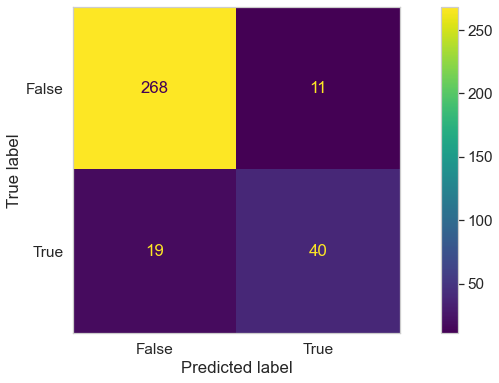

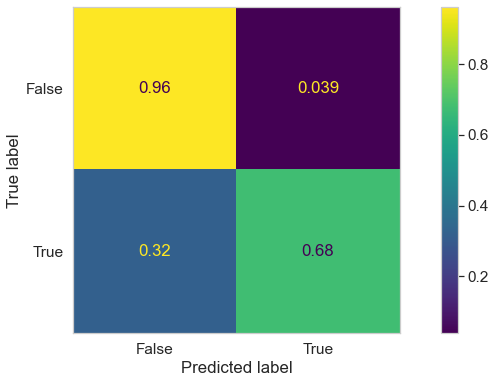

In [152]:

from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score
# 성능지표
from sklearn.metrics import accuracy_score, plot_roc_curve 
from sklearn.metrics import plot_confusion_matrix, classification_report
# 파이프라인
from sklearn.pipeline import Pipeline, make_pipeline
# 시각화 툴
import scikitplot as skplt


y_predict = rf.fit(X_train, y_train).predict(X_test)
accuracy_score(y_test, y_predict)
print(classification_report(y_test, y_predict))
sns.set_style("whitegrid", {'axes.grid' : False})
plot_confusion_matrix(rf, X_test, y_test)
plot_confusion_matrix(rf, X_test, y_test, normalize='true')

In [153]:
#rf = ensemble.RandomForestClassifier(n_estimators=300, oob_score=True, random_state=1357,  class_weight='balanced')
rf.fit(X_train, y_train)
y_predict = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_predict)
print(f'Mean accuracy score: {accuracy:.3}')
print(f'Out-of-bag score estimate: {rf.oob_score_:.3}')
print(classification_report(y_test, y_predict))

LogisticRegression(random_state=0)

Mean accuracy score: 0.911


AttributeError: 'LogisticRegression' object has no attribute 'oob_score_'

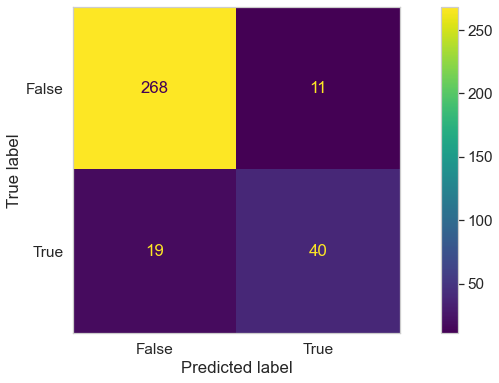

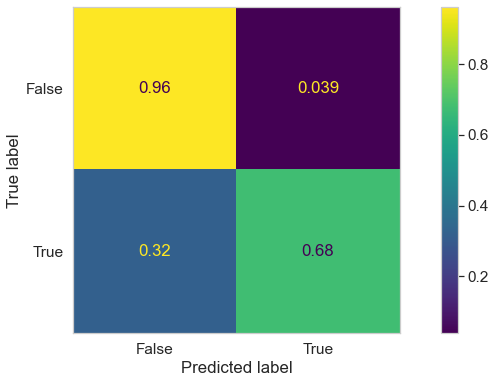

In [154]:
sns.set_style("whitegrid", {'axes.grid' : False})
plot_confusion_matrix(rf, X_test, y_test)
plot_confusion_matrix(rf, X_test, y_test, normalize='true')

<AxesSubplot:title={'center':'Lift Curve'}, xlabel='Percentage of sample', ylabel='Lift'>

<AxesSubplot:title={'center':'Cumulative Gains Curve'}, xlabel='Percentage of sample', ylabel='Gain'>

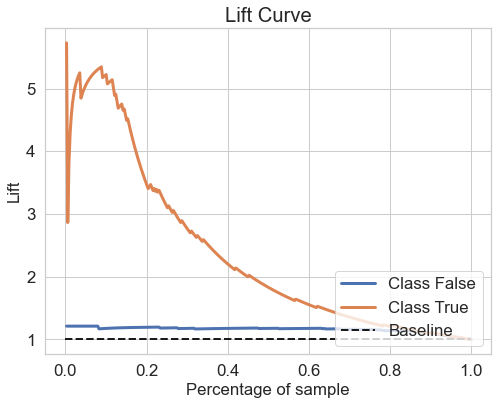

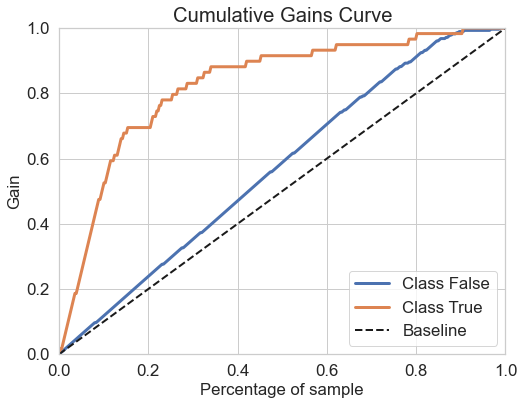

In [155]:
plt.rcParams["figure.figsize"] = (8,6)
y_proba = rf.predict_proba(X_test)
skplt.metrics.plot_lift_curve(y_test, y_proba)
skplt.metrics.plot_cumulative_gain(y_test, y_proba)

<AxesSubplot:title={'center':'KS Statistic Plot'}, xlabel='Threshold', ylabel='Percentage below threshold'>

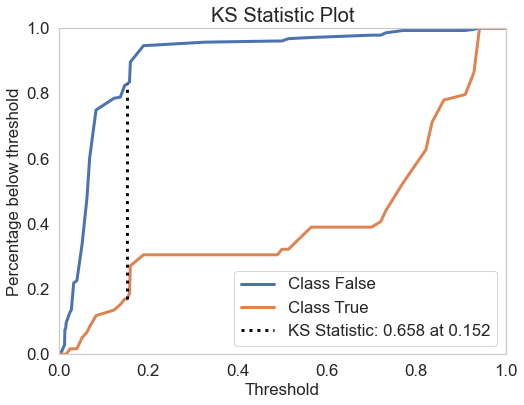

In [156]:
skplt.metrics.plot_ks_statistic(y_test, y_proba)

<AxesSubplot:title={'center':'ROC Curves'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

<AxesSubplot:title={'center':'Precision-Recall Curve'}, xlabel='Recall', ylabel='Precision'>

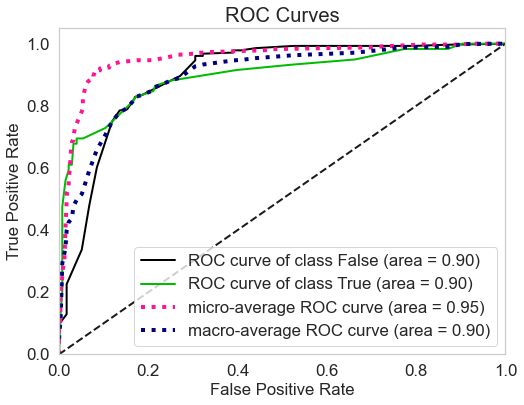

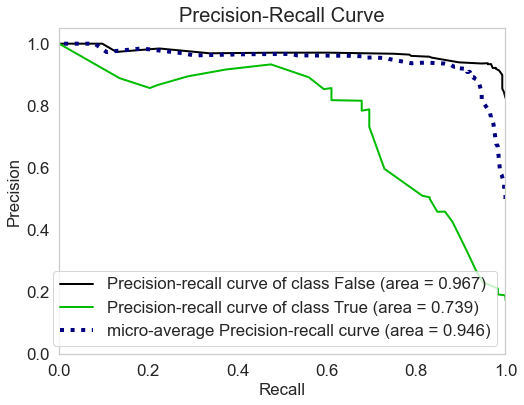

In [157]:
skplt.metrics.plot_roc(y_test, y_proba)
skplt.metrics.plot_precision_recall(y_test, y_proba)

In [158]:
from sklearn.metrics import precision_recall_curve
def to_labels(pos_probs, threshold):
    return (pos_probs >= threshold).astype('int')
p, r, thresholds = precision_recall_curve(y_test, y_proba[:, 1])
scores = [np.sum(to_labels(y_proba[:, 1], t))/len(y_proba[:, 1]) for t in thresholds]

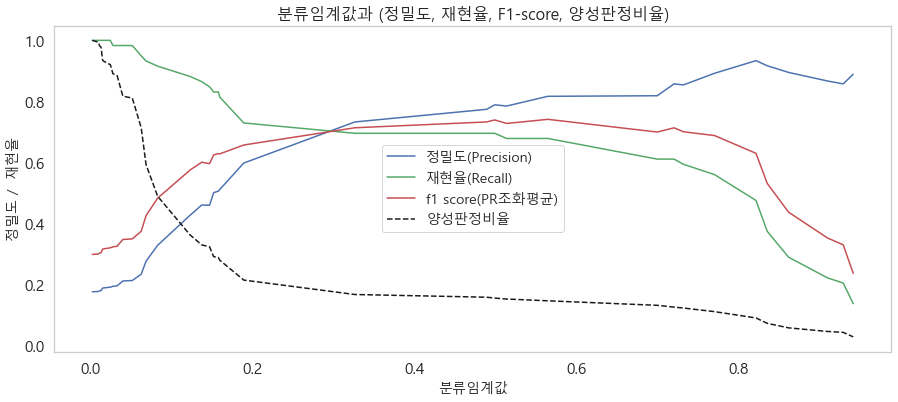

In [159]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds): 
    plt.rcParams["figure.figsize"] = (15,6)
    plt.rcParams['font.family']='Malgun Gothic' # 한글폰트
    plt.title('분류임계값과 (정밀도, 재현율, F1-score, 양성판정비율)', fontsize='16') 
    plt.plot(thresholds, precisions[:-1], 'b-', label='정밀도(Precision)') # 판사
    plt.plot(thresholds, recalls[:-1], 'g-', label='재현율(Recall)') # 검사
    plt.plot(thresholds, (2*precisions[:-1]*recalls[:-1])/(precisions[:-1] +recalls[:-1]), 
             'r-', label='f1 score(PR조화평균)') # 변호사
    plt.plot(thresholds, scores, 'k--', label='양성판정비율') # q-ratio
    plt.ylabel('정밀도 /  재현율', fontsize='14') 
    plt.xlabel('분류임계값', fontsize='14') 
    plt.legend(loc='best', fontsize='14') 
plot_precision_recall_vs_threshold(p, r, thresholds)

  0%|          | 0/1 [00:00<?, ?it/s]

<AxesSubplot:title={'center':'Calibration plots (Reliability Curves)'}, xlabel='Mean predicted value', ylabel='Fraction of positives'>

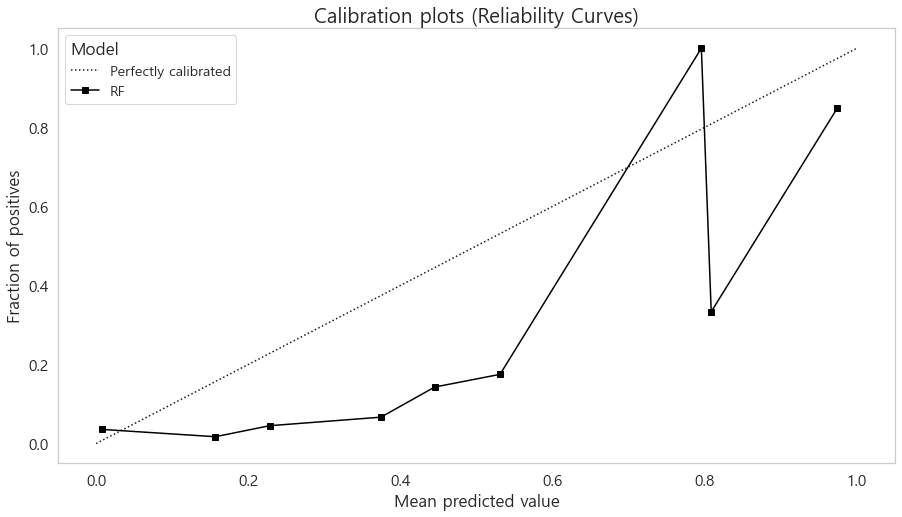

In [160]:
classifiers = {}
#classifiers.update({'GNB': GaussianNB()})
#classifiers.update({'LGR': LogisticRegression(class_weight='balanced')})
#classifiers.update({'SVC': SVC(probability=True)})
classifiers.update({'RF': ensemble.RandomForestClassifier(n_estimators=100, class_weight='balanced')})
from tqdm import tqdm_notebook
classifier_labels = []
probas_list = []
for classifier_label, classifier in tqdm_notebook(classifiers.items()):
    y_proba = classifier.fit(X_train, y_train).predict_proba(X_test)
    probas_list.append(y_proba)
    classifier_labels.append(classifier_label)

skplt.metrics.plot_calibration_curve(y_test, probas_list, classifier_labels, figsize=(15,8))
leg = plt.legend(title='Model', fontsize = 14)
leg._legend_box.align = 'left'

(array([25., 29., 65., 33., 55., 63.,  2., 32., 32.,  2.]),
 array([0.        , 0.09557055, 0.1911411 , 0.28671165, 0.3822822 ,
        0.47785275, 0.5734233 , 0.66899385, 0.7645644 , 0.86013495,
        0.9557055 ]),
 <BarContainer object of 10 artists>)

(array([ 2., 32., 32.,  2., 63., 55., 33., 65., 29., 25.]),
 array([0.0442945 , 0.13986505, 0.2354356 , 0.33100615, 0.4265767 ,
        0.52214725, 0.6177178 , 0.71328835, 0.8088589 , 0.90442945,
        1.        ]),
 <BarContainer object of 10 artists>)

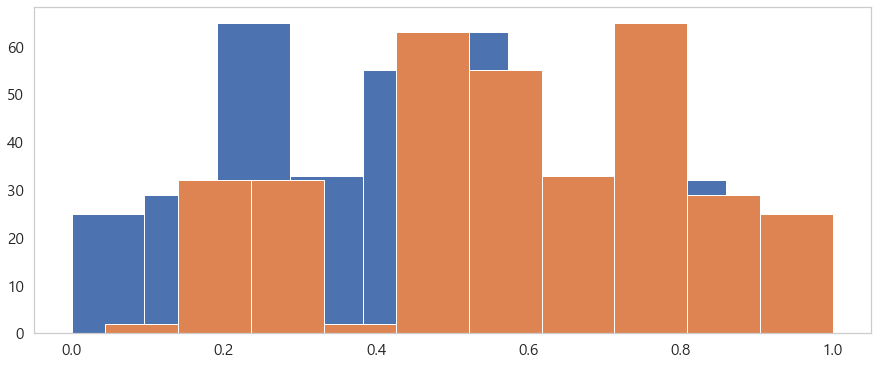

In [105]:
plt.hist(y_proba[:, 1]) 
plt.hist(y_proba[:, 0]) 

In [106]:
data = pd.DataFrame(np.c_[y_proba[:,1], y_test], columns=['Predicted Probability','True Label'])
data

,Predicted Probability,True Label
0,0.000000,0.0
1,0.580505,0.0
2,0.460638,0.0
3,0.758543,0.0
4,0.065696,0.0
...,...,...
333,0.542459,0.0
334,0.148652,0.0
335,0.527940,0.0
336,0.065696,0.0


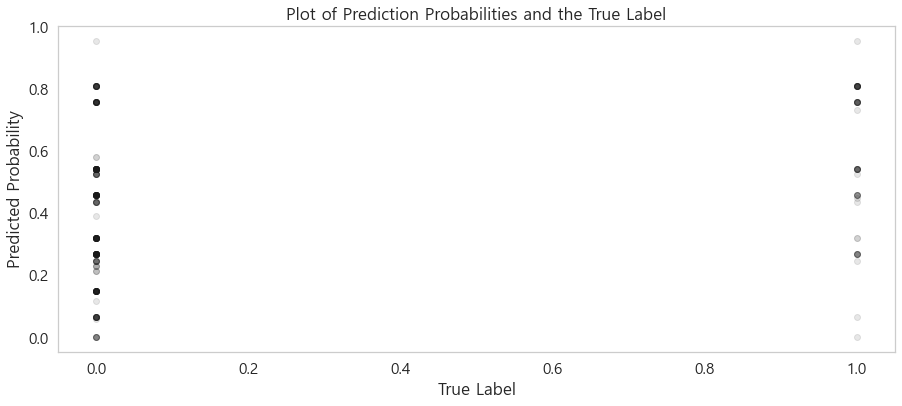

In [107]:
ax = sns.regplot(x="True Label", y="Predicted Probability", color='k', 
                 fit_reg=False, scatter_kws={'alpha':0.1},
                 data=data).set_title('Plot of Prediction Probabilities and the True Label')

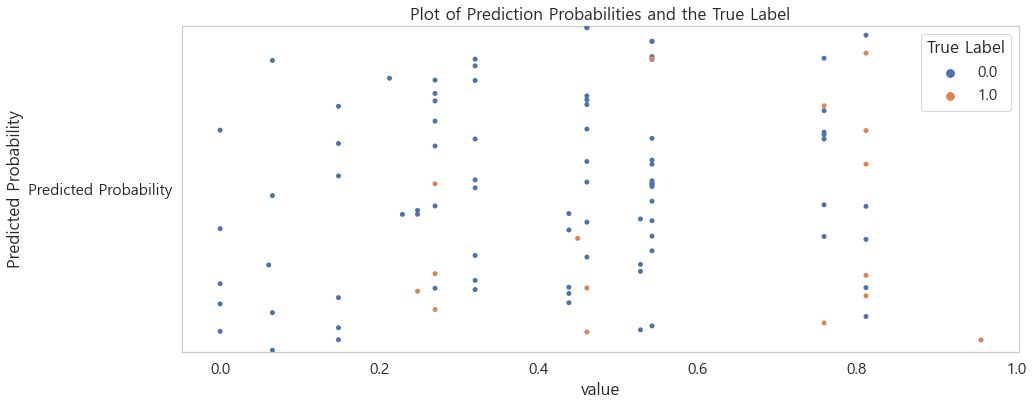

In [108]:
datamelted = pd.melt(data, "True Label", var_name="Predicted Probability")
ax = sns.stripplot(x="value", y="Predicted Probability",
                   hue='True Label', jitter=0.5,
                   data=datamelted.sample(100, random_state=13)).set_title('Plot of Prediction Probabilities and the True Label')

## 백분위수 (Decile) 분석

In [161]:
data = pd.DataFrame({'actual_y' : y_test, 'probability_y' : y_proba[:, 1]}).sort_values('probability_y', ascending=False)
data

,actual_y,probability_y
1110,True,1.0
997,True,1.0
662,True,1.0
778,True,1.0
245,True,1.0
...,...,...
1296,False,0.0
1434,False,0.0
1483,False,0.0
1467,False,0.0


In [162]:
pd.qcut(data["probability_y"], q = 8)

1110       (0.906, 1.0]
997        (0.906, 1.0]
662        (0.906, 1.0]
778        (0.906, 1.0]
245        (0.906, 1.0]
             ...       
1296    (-0.001, 0.133]
1434    (-0.001, 0.133]
1483    (-0.001, 0.133]
1467    (-0.001, 0.133]
1334    (-0.001, 0.133]
Name: probability_y, Length: 338, dtype: category
Categories (8, interval[float64, right]): [(-0.001, 0.133] < (0.133, 0.172] < (0.172, 0.209] < (0.209, 0.24] < (0.24, 0.243] < (0.243, 0.509] < (0.509, 0.906] < (0.906, 1.0]]

In [163]:
tf = pd.DataFrame({'actual_y' : y_test, 'probability_y' : y_proba[:, 1]}).sort_values('probability_y', ascending=False)

tf['decile'] = pd.qcut(tf["probability_y"], q = 8, labels = list(range(8, 0, -1)))
tf.head()

,actual_y,probability_y,decile
1110,True,1.0,1
997,True,1.0,1
662,True,1.0,1
778,True,1.0,1
245,True,1.0,1


In [164]:
tf.groupby('decile')['actual_y'].sum(0)
tf.groupby('decile')['actual_y'].sum(0)/tf.groupby('decile')['actual_y'].count()*100
for i, g in tf.groupby('decile'):
    unfit_ratio = g['actual_y'].value_counts(normalize=True)[1].round(2)*100
    print(f'{i} percentile의 부적합율 {unfit_ratio}')

decile
8     1
7     1
6     1
5     3
4     2
3     5
2    11
1    35
Name: actual_y, dtype: int64

decile
8     1.960784
7     2.857143
6     2.439024
5     6.818182
4     4.651163
3    10.000000
2    33.333333
1    85.365854
Name: actual_y, dtype: float64

8 percentile의 부적합율 2.0
7 percentile의 부적합율 3.0
6 percentile의 부적합율 2.0
5 percentile의 부적합율 7.000000000000001
4 percentile의 부적합율 5.0
3 percentile의 부적합율 10.0
2 percentile의 부적합율 33.0
1 percentile의 부적합율 85.0


<Figure size 720x360 with 0 Axes>

<AxesSubplot:xlabel='decile', ylabel='actual_y'>

Text(0.5, 1.0, '백분위 별 실제 부적합 건수')

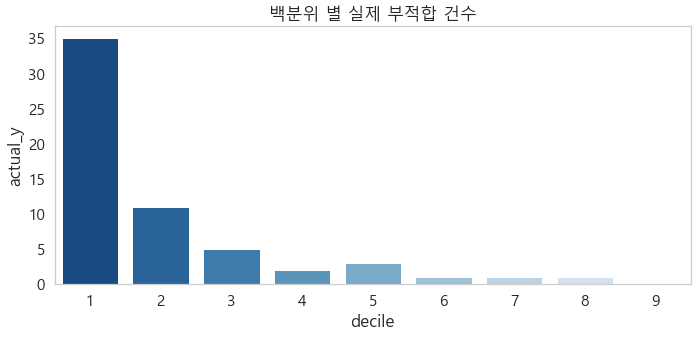

In [165]:
data = tf[['actual_y', 'decile']].groupby("decile").sum().reset_index().sort_values('decile', ascending=False)
plt.figure(figsize = (10,5))
sns.barplot(x = 'decile', y = 'actual_y', data = data, order = range(1, 10), palette = 'Blues_r')
plt.title("백분위 별 실제 부적합 건수")
plt.tight_layout()

RandomForestClassifier(n_estimators=300, oob_score=True, random_state=1357)

<Figure size 1800x360 with 0 Axes>

Text(0, 0.5, 'Features Importance')

Text(0.5, 1.0, '변수 중요도')

([<matplotlib.axis.XTick at 0x1f3af715250>,
 [Text(0, 0, '대표자성명'),
  Text(1, 0, '주소'),
  Text(2, 0, '전화번호'),
  Text(3, 0, '이메일'),
  Text(4, 0, '회사이메일'),
  Text(5, 0, '팩스'),
  Text(6, 0, '인증'),
  Text(7, 0, '공식인증'),
  Text(8, 0, '수산물'),
  Text(9, 0, 'N'),
  Text(10, 0, 'S'),
  Text(11, 0, 'Y')])

<BarContainer object of 12 artists>

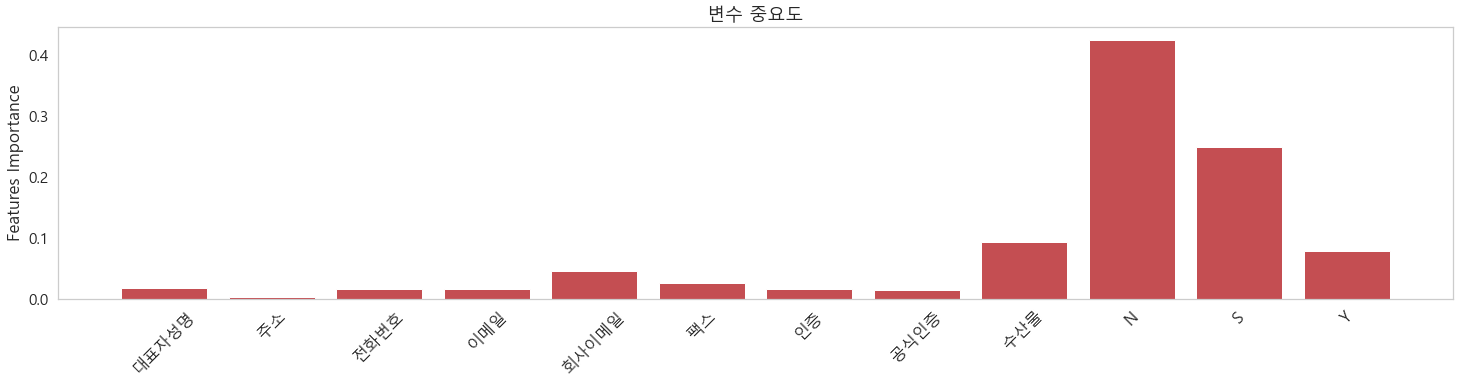

In [166]:
from sklearn.tree import DecisionTreeClassifier
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, 
                                                  stratify= y, random_state=11)
dt = ensemble.RandomForestClassifier(n_estimators=300, oob_score=True, random_state=1357)
dt.fit(X, y)
plt.figure(figsize=(25,5)); plt.ylabel('Features Importance')
plt.title('변수 중요도', fontsize=18)
plt.xticks(np.arange(X.shape[1]), X.columns, rotation='45', fontsize=16)
plt.bar(range(X.shape[1]), dt.feature_importances_, color='r')

<Figure size 1800x432 with 0 Axes>

Text(0, 0.5, 'Features Permutation Importance')

Text(0.5, 1.0, '의사결정트리의 변수 Permutation 중요도')

([<matplotlib.axis.XTick at 0x2bee9c23c10>,
 [Text(0, 0, '대표자성명'),
  Text(1, 0, '주소'),
  Text(2, 0, '전화번호'),
  Text(3, 0, '이메일'),
  Text(4, 0, '회사이메일'),
  Text(5, 0, '팩스'),
  Text(6, 0, '인증'),
  Text(7, 0, '공식인증'),
  Text(8, 0, '수산물'),
  Text(9, 0, 'N'),
  Text(10, 0, 'S'),
  Text(11, 0, 'Y')])

<BarContainer object of 12 artists>

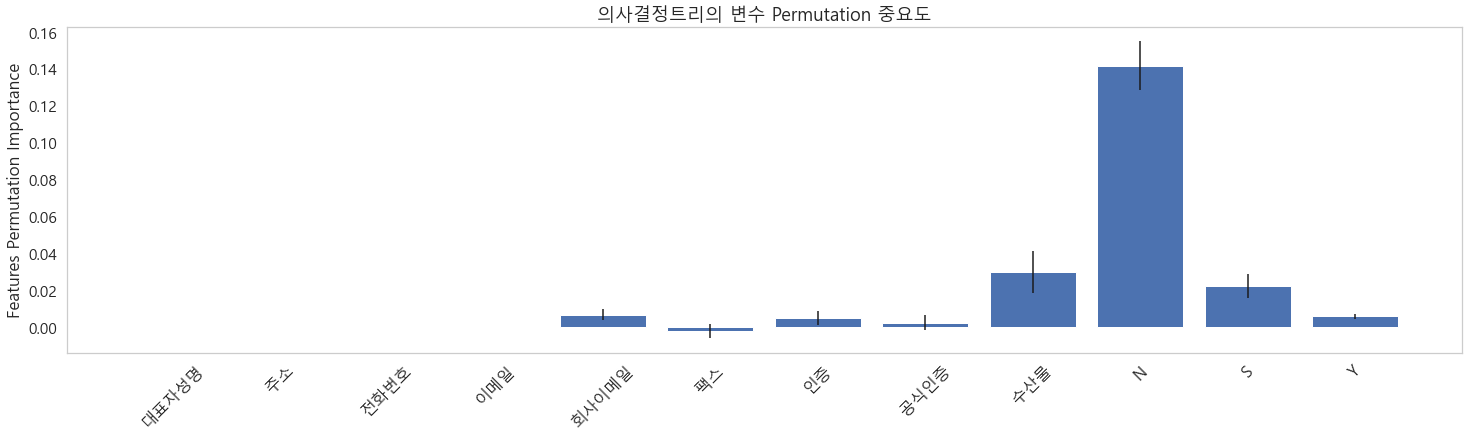

In [68]:
from sklearn.inspection import permutation_importance
result = permutation_importance(dt, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2)
feature_names = [f'feature {i}' for i in range(X.shape[1])]
forest_importances = pd.Series(result.importances_mean, index=feature_names)
plt.figure(figsize=(25,6)); plt.ylabel('Features Permutation Importance')
plt.title('의사결정트리의 변수 Permutation 중요도', fontsize=18)
plt.xticks(np.arange(X.shape[1]), X.columns, rotation='45', fontsize=16)
plt.bar(range(X.shape[1]), forest_importances, yerr=result.importances_std, color='b')

In [88]:
from sklearn.model_selection import KFold
from sklearn.model_selection import RandomizedSearchCV
params = {
    'criterion' :['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth' : np.arange(1,15),
    'min_samples_split': np.arange(0.005, 0.1, 0.001),
    'min_samples_leaf': [0.005, 0.01, 0.05, 0.10], # np.arange(0.005, 0.1, 0.001)
    'max_features': ['auto', 'sqrt', 'log2'],
}
np.random.seed(1111)
kf = KFold(n_splits=2)
model = DecisionTreeClassifier(random_state=11)
grid = RandomizedSearchCV(model, params, cv=kf, n_iter=50, 
                          scoring = 'recall_macro', verbose =True)
grid.fit(X_train, y_train)
print(f'optimal parameter: {grid.best_params_}')

Fitting 2 folds for each of 50 candidates, totalling 100 fits


RandomizedSearchCV(cv=KFold(n_splits=2, random_state=None, shuffle=False),
                   estimator=DecisionTreeClassifier(random_state=11), n_iter=50,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': [0.005, 0.01, 0.05,
                                                             0.1],
                                        'min_samples_split': array([0.005,...
       0.05 , 0.051, 0.052, 0.053, 0.054, 0.055, 0.056, 0.057, 0.058,
       0.059, 0.06 , 0.061, 0.062, 0.063, 0.064, 0.065, 0.066, 0.067,
       0.068, 0.069, 0.07 , 0.071, 0.072, 0.073, 0.074, 0.075, 0.076,
       0.077, 0.078, 0.079, 0.08 , 0.081, 0.082, 0.083, 0.084, 0.085,
       0.086, 0.087, 0.088, 0.089, 0.09 , 0.091, 0.092, 0.093, 0.094,
       0.095, 0.096, 0.097, 0.098, 0.099]),
                                        'splitter': ['best', 'random']},
                   scoring='recall_macro', verbose=True)

optimal parameter: {'splitter': 'best', 'min_samples_split': 0.019, 'min_samples_leaf': 0.005, 'max_features': 'auto', 'max_depth': 4, 'criterion': 'entropy'}


In [89]:
model= DecisionTreeClassifier(random_state=11).set_params(**grid.best_params_)
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, max_features='auto',
                       min_samples_leaf=0.005, min_samples_split=0.019,
                       random_state=11)

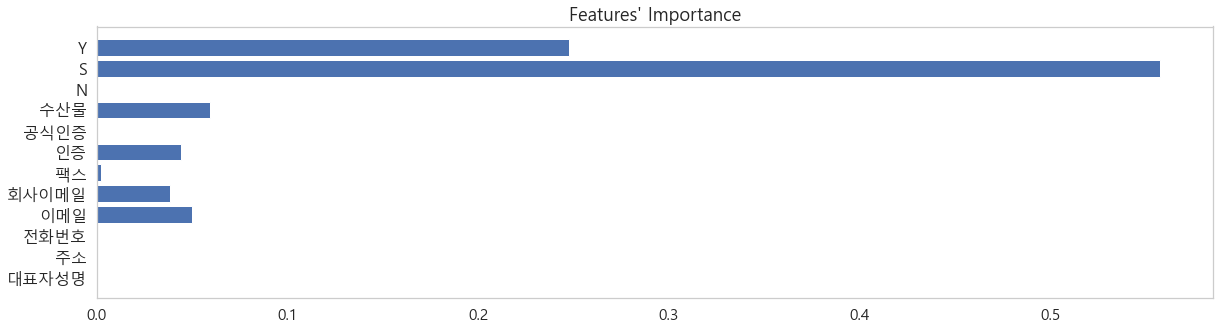

In [90]:
def plot_feature_importances(model):
    fig, ax = plt.subplots(1,1,figsize=(20,5))
    plt.barh(range(X_train.shape[1]), model.feature_importances_, align='center')
    plt.yticks(np.arange(X_train.shape[1]), X_train.columns, fontsize=16)
    plt.title("Features' Importance", fontsize=18)
    
plot_feature_importances(model)

## 로지스틱회귀모형으로 해석

In [167]:
model = LogisticRegression(solver='saga', random_state=11)
params = {'C': np.logspace(-4, 4, 20), 'penalty': ['l1', 'l2']}
grid = RandomizedSearchCV(model, param_distributions=params, cv=kf,
                          scoring = 'recall')
grid.fit(X_train, y_train)
print('optimal train score: {:.3f}'.format(grid.best_score_))
print('test score: {:.3f}'.format(grid.score(X_test, y_test)))
print('optimal parameter: {}'.format(grid.best_params_))

RandomizedSearchCV(cv=KFold(n_splits=2, random_state=None, shuffle=False),
                   estimator=LogisticRegression(random_state=11, solver='saga'),
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'penalty': ['l1', 'l2']},
                   scoring='recall')

optimal train score: 0.544
test score: 0.679
optimal parameter: {'penalty': 'l2', 'C': 29.763514416313132}


In [168]:
model= LogisticRegression(random_state=11, solver='saga').set_params(**grid.best_params_)
model.get_params()
model.fit(X_train, y_train)
model.intercept_

{'C': 29.763514416313132,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'auto',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': 11,
 'solver': 'saga',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

LogisticRegression(C=29.763514416313132, random_state=11, solver='saga')

array([-1.93571053])

In [172]:
model.coef_

array([[ 0.85623729,  0.00471366,  1.33273846,  0.95005867, -0.8310489 ,
        -0.1774501 , -1.48390461,  1.07820723, -2.01254373, -2.7451035 ,
         1.56756549,  0.04035808]])

<AxesSubplot:xlabel='variable'>

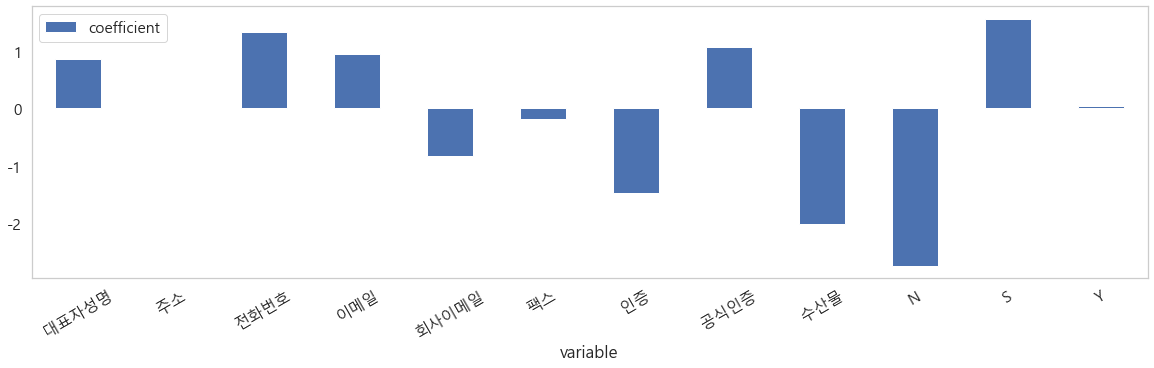

In [171]:
data = zip(X_train.columns, np.squeeze(model.coef_))
(pd.DataFrame(data, columns =['variable', 'coefficient']).set_index('variable').
plot.bar(rot='30', figsize=(20,5)))

In [72]:
X

,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,S,Y
0,True,True,True,True,False,False,False,False,False,True,False,False
1,True,True,True,True,False,False,False,False,False,True,False,False
2,True,True,True,True,True,True,False,False,False,True,False,False
3,True,True,True,True,True,False,False,False,False,True,False,False
4,True,True,True,True,False,True,True,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
1684,True,True,True,True,True,False,True,True,False,True,False,False
1685,True,True,True,True,True,False,True,True,False,True,False,False
1686,True,True,True,True,True,True,True,True,False,True,False,False
1687,True,True,True,True,True,False,True,True,False,True,False,False


In [110]:
import xgboost
import shap
# train an XGBoost model
#X, y =shap.datasets.adult()
X.head(10)
y[0:10]

,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,S,Y
0,True,True,True,True,False,False,False,False,False,True,False,False
1,True,True,True,True,False,False,False,False,False,True,False,False
2,True,True,True,True,True,True,False,False,False,True,False,False
3,True,True,True,True,True,False,False,False,False,True,False,False
4,True,True,True,True,False,True,True,True,False,False,False,True
5,True,True,True,True,True,True,True,True,False,True,False,False
6,True,True,True,True,False,False,False,False,False,False,True,False
7,True,True,True,True,True,False,False,False,False,True,False,False
8,True,True,True,True,True,True,False,False,False,True,False,False
9,True,True,True,True,True,True,True,True,False,True,False,False


0    False
1    False
2    False
3    False
4    False
5    False
6     True
7    False
8    False
9    False
Name: target, dtype: bool

.values =
array([ 1.0381656e-02, -2.3209922e-04,  1.7782761e-02,  1.7344324e-02,
        6.3805431e-01,  5.8674213e-02, -6.2427752e-02,  1.4393292e-01,
        1.5224051e-01, -5.7675129e-01, -8.3331987e-02,  4.0792935e-03],
      dtype=float32)

.base_values =
-1.981489

.data =
array([ True,  True,  True,  True, False, False, False, False, False,
        True, False, False])

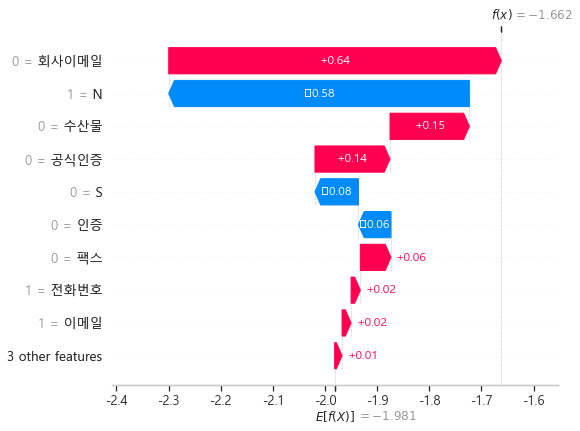

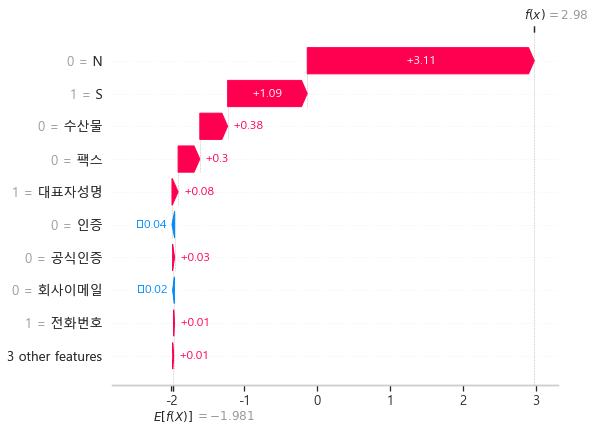

In [138]:
model = xgboost.XGBClassifier(eval_metric='mlogloss').fit(X, y)
explainer = shap.Explainer(model) # explainer = shap.Explainer(model, X)
shap_values = explainer(X)
shap_values[0]
shap.plots.waterfall(shap_values[0])
shap.plots.waterfall(shap_values[6])

In [140]:
explainer = shap.TreeExplainer(model) 
shap_values = explainer.shap_values(X)
shap.initjs()
shap.plots.force(explainer.expected_value, shap_values[0])
shap.plots.force(explainer.expected_value, shap_values[6])

In [141]:
shap_values
print(f'\n\n원자료의 크기{X.shape}와 SHAP value의 크기{shap_values.shape}')

array([[ 1.03816558e-02, -2.32099221e-04,  1.77827608e-02, ...,
        -5.76751292e-01, -8.33319873e-02,  4.07929346e-03],
       [ 1.03816558e-02, -2.32099221e-04,  1.77827608e-02, ...,
        -5.76751292e-01, -8.33319873e-02,  4.07929346e-03],
       [ 1.66005399e-02, -2.99372594e-04,  1.22792488e-02, ...,
        -6.08922541e-01, -1.29786968e-01,  5.70906326e-03],
       ...,
       [ 1.74639486e-02, -2.63769180e-04,  1.40949460e-02, ...,
        -6.94128096e-01, -1.27698302e-01, -7.80159608e-03],
       [ 1.59846842e-02, -2.51979276e-04,  1.32445805e-02, ...,
        -5.64298272e-01, -1.53642759e-01,  9.12466366e-03],
       [ 1.59846842e-02,  2.90983059e-02,  1.31562594e-02, ...,
        -5.64298272e-01, -1.53642759e-01,  5.22305584e-03]], dtype=float32)



원자료의 크기(1689, 12)와 SHAP value의 크기(1689, 12)


In [142]:
data = pd.DataFrame(shap_values, columns = X.columns)
data['sum of SHAP'] = data.sum(1)  # 특성 변수의 SHAP values
data['average mean of model prediction'] = np.mean(model.predict(X))
data['prediction value by shap'] = data['sum of SHAP'] + data['average mean of model prediction']
#data['prediction by model'] = model.predict(X)
data['prediction by model'] = model.predict(X)

In [143]:
data.head(10)
shap_values[0]
shap_values[6]

,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,S,Y,sum of SHAP,average mean of model prediction,prediction value by shap,prediction by model
0,0.010382,-0.000232,0.017783,0.017344,0.638054,0.058674,-0.062428,0.143933,0.152241,-0.576751,-0.083332,0.004079,0.319747,0.113085,0.432832,False
1,0.010382,-0.000232,0.017783,0.017344,0.638054,0.058674,-0.062428,0.143933,0.152241,-0.576751,-0.083332,0.004079,0.319747,0.113085,0.432832,False
2,0.016601,-0.000299,0.012279,0.005168,-0.600591,-0.165883,0.053174,-0.115983,0.284141,-0.608923,-0.129787,0.005709,-1.244395,0.113085,-1.131310,False
3,0.016841,-0.000177,0.015180,0.009160,-0.442152,0.187368,0.038118,0.023618,0.144584,-0.658546,-0.130841,0.004295,-0.792551,0.113085,-0.679466,False
4,0.128722,-0.000262,0.012712,0.005587,-0.017998,0.061702,-0.425770,-0.012166,0.286549,2.332754,-0.475846,-0.050349,1.845634,0.113085,1.958719,False
5,0.017464,-0.000264,0.014095,0.005792,-0.359580,0.014154,-0.057443,0.157720,0.271959,-0.694128,-0.127698,-0.007802,-0.765730,0.113085,-0.652645,False
6,0.084166,-0.000232,0.009669,0.009641,-0.024451,0.297749,-0.035820,0.027432,0.381617,3.114963,1.092446,0.004079,4.961259,0.113085,5.074344,True
7,0.016841,-0.000177,0.015180,0.009160,-0.442152,0.187368,0.038118,0.023618,0.144584,-0.658546,-0.130841,0.004295,-0.792551,0.113085,-0.679466,False
8,0.016601,-0.000299,0.012279,0.005168,-0.600591,-0.165883,0.053174,-0.115983,0.284141,-0.608923,-0.129787,0.005709,-1.244395,0.113085,-1.131310,False
9,0.017464,-0.000264,0.014095,0.005792,-0.359580,0.014154,-0.057443,0.157720,0.271959,-0.694128,-0.127698,-0.007802,-0.765730,0.113085,-0.652645,False


array([ 1.0381656e-02, -2.3209922e-04,  1.7782761e-02,  1.7344324e-02,
        6.3805431e-01,  5.8674213e-02, -6.2427752e-02,  1.4393292e-01,
        1.5224051e-01, -5.7675129e-01, -8.3331987e-02,  4.0792935e-03],
      dtype=float32)

array([ 8.4165625e-02, -2.3209922e-04,  9.6690962e-03,  9.6412878e-03,
       -2.4450889e-02,  2.9774892e-01, -3.5820067e-02,  2.7432149e-02,
        3.8161728e-01,  3.1149628e+00,  1.0924460e+00,  4.0792935e-03],
      dtype=float32)

In [147]:
data = pd.DataFrame(shap_values, columns = X.columns)
data['SUM'] = data.sum(1)  # 특성 변수의 SHAP values
data['f(x)'] = model.predict(X)
data['E[f(x)]'] = np.mean(model.predict(X))
data['SUM + E[f(x)]'] = data['SUM'] + data['E[f(x)]']
data.head(10)

,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,S,Y,SUM,f(x),E[f(x)],SUM + E[f(x)]
0,0.010382,-0.000232,0.017783,0.017344,0.638054,0.058674,-0.062428,0.143933,0.152241,-0.576751,-0.083332,0.004079,0.319747,False,0.113085,0.432832
1,0.010382,-0.000232,0.017783,0.017344,0.638054,0.058674,-0.062428,0.143933,0.152241,-0.576751,-0.083332,0.004079,0.319747,False,0.113085,0.432832
2,0.016601,-0.000299,0.012279,0.005168,-0.600591,-0.165883,0.053174,-0.115983,0.284141,-0.608923,-0.129787,0.005709,-1.244395,False,0.113085,-1.131310
3,0.016841,-0.000177,0.015180,0.009160,-0.442152,0.187368,0.038118,0.023618,0.144584,-0.658546,-0.130841,0.004295,-0.792551,False,0.113085,-0.679466
4,0.128722,-0.000262,0.012712,0.005587,-0.017998,0.061702,-0.425770,-0.012166,0.286549,2.332754,-0.475846,-0.050349,1.845634,False,0.113085,1.958719
5,0.017464,-0.000264,0.014095,0.005792,-0.359580,0.014154,-0.057443,0.157720,0.271959,-0.694128,-0.127698,-0.007802,-0.765730,False,0.113085,-0.652645
6,0.084166,-0.000232,0.009669,0.009641,-0.024451,0.297749,-0.035820,0.027432,0.381617,3.114963,1.092446,0.004079,4.961259,True,0.113085,5.074344
7,0.016841,-0.000177,0.015180,0.009160,-0.442152,0.187368,0.038118,0.023618,0.144584,-0.658546,-0.130841,0.004295,-0.792551,False,0.113085,-0.679466
8,0.016601,-0.000299,0.012279,0.005168,-0.600591,-0.165883,0.053174,-0.115983,0.284141,-0.608923,-0.129787,0.005709,-1.244395,False,0.113085,-1.131310
9,0.017464,-0.000264,0.014095,0.005792,-0.359580,0.014154,-0.057443,0.157720,0.271959,-0.694128,-0.127698,-0.007802,-0.765730,False,0.113085,-0.652645


In [157]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values)

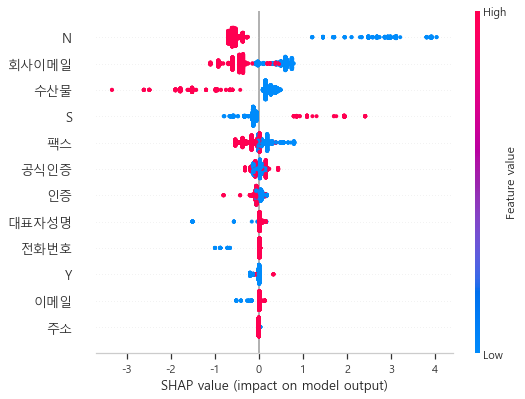

In [79]:
shap.summary_plot(shap_values, X)

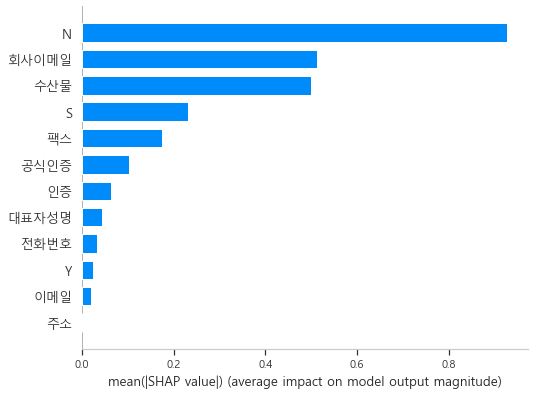

In [80]:
shap.summary_plot(shap_values, X, plot_type="bar")

# Pycaret

In [2]:
# https://pycaret.gitbook.io/docs/#classification
# 준비
from pycaret.classification import *
import pandas as pd

In [29]:
data = pd.read_pickle('../working_ml/data_01_대장.pkl').reset_index(drop=True).iloc[:,2:]
data

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,R,S,Y,target
0,True,True,True,True,True,False,False,False,False,False,True,False,False,False,False
1,True,True,True,True,True,False,False,False,False,False,True,False,False,False,False
2,True,True,True,True,True,True,True,False,False,False,True,False,False,False,False
3,True,True,True,True,True,True,False,False,False,False,True,False,False,False,False
4,True,True,True,True,True,False,True,True,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1684,True,True,True,True,True,True,False,True,True,False,True,False,False,False,False
1685,True,True,True,True,True,True,False,True,True,False,True,False,False,False,False
1686,True,True,True,True,True,True,True,True,True,False,True,False,False,False,False
1687,True,True,True,True,True,True,False,True,True,False,True,False,False,False,False


In [30]:
# data.drop(['업소명','R','N','S'], axis=1, inplace=True)
data.drop(['업소명','R'], axis=1, inplace=True)

In [31]:
data.corr().shape

(13, 13)

In [32]:
train = data.sample(frac=0.8)
test = data[~data.index.isin(train.index)]

In [33]:
train.shape, test.shape

((1351, 13), (338, 13))

In [34]:
clf1 = setup(data = train, target = 'target', silent=True, fix_imbalance=True)

,Description,Value
0,session_id,344
1,Target,target
2,Target Type,Binary
3,Label Encoded,"False: 0, True: 1"
4,Original Data,"(1351, 13)"
5,Missing Values,False
6,Numeric Features,0
7,Categorical Features,12
8,Ordinal Features,False
9,High Cardinality Features,False


In [35]:
# model training and selection
# best = compare_models()
# best = compare_models(include=['knn'])
best = compare_models(exclude=['knn','qda','dummy'])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.8931,0.0000,0.6239,0.7190,0.6595,0.5976,0.6047,0.0130
lda,Linear Discriminant Analysis,0.8931,0.8603,0.6239,0.7190,0.6595,0.5976,0.6047,0.0140
ada,Ada Boost Classifier,0.8856,0.8583,0.6474,0.6908,0.6570,0.5897,0.5971,0.0700
nb,Naive Bayes,0.8742,0.8581,0.6294,0.7031,0.6383,0.5670,0.5840,0.0140
lr,Logistic Regression,0.8739,0.8562,0.6665,0.6585,0.6426,0.5689,0.5818,0.0210
lightgbm,Light Gradient Boosting Machine,0.8634,0.8649,0.7107,0.6017,0.6403,0.5583,0.5693,0.0340
rf,Random Forest Classifier,0.8613,0.8614,0.7044,0.5997,0.6367,0.5535,0.5639,0.2540
xgboost,Extreme Gradient Boosting,0.8613,0.8629,0.6982,0.5961,0.6315,0.5483,0.5592,0.1760
gbc,Gradient Boosting Classifier,0.8602,0.8599,0.7169,0.5896,0.6379,0.5540,0.5646,0.0750
et,Extra Trees Classifier,0.8591,0.8609,0.7044,0.5935,0.6326,0.5481,0.5593,0.2180


In [36]:
# 모델 평가
evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Hyperparameters', 'param…

In [37]:
interpret_model(best, plot = 'pfi')

12it [00:00, 73.51it/s]


In [13]:
# test set으로 예측
predictions = predict_model(best, data = test)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,K Neighbors Classifier,0.9201,0.8422,0.6607,0.8222,0.7327,0.6864,0.6920


In [14]:
predictions

,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,S,Y,target,Label,Score
11,True,True,True,True,False,True,False,False,False,True,False,True,True,1.0
13,True,True,True,True,True,False,True,True,False,False,False,False,False,1.0
19,True,True,True,True,True,True,False,False,False,False,False,False,False,1.0
30,True,True,True,True,False,False,False,False,False,False,False,False,False,1.0
32,True,True,True,True,False,True,False,False,False,False,False,False,False,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1660,True,True,True,True,True,True,True,True,False,False,False,False,False,1.0
1670,True,True,True,True,True,False,False,False,False,False,False,True,False,1.0
1674,True,True,True,True,False,True,False,False,False,False,True,True,True,0.6
1679,True,True,True,True,True,True,False,False,False,False,False,False,False,1.0


In [15]:
predictions['target'].value_counts()

False    282
True      56
Name: target, dtype: int64

In [16]:
# predictions['Label'].replace({'False':False,'True':True})

In [17]:
predictions.groupby('target').Label.value_counts().unstack()

Label,False,True
target,,
False,274,8
True,19,37


In [16]:
test

,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,...,NV.IND.TOTL.ZS,NY.GDP.DEFL.KD.ZG,NY.GDP.PCAP.CD,NY.GDP.PCAP.KD.ZG,SL.EMP.TOTL.SP.ZS,SL.UEM.TOTL.ZS,SP.DYN.LE00.IN,SP.URB.TOTL.IN.ZS,TG.VAL.TOTL.GD.ZS,target
3,True,True,True,True,False,True,False,False,False,True,...,37.820917,0.625194,10434.775187,2.116523,64.778999,4.817000,77.097,61.428,31.566413,True
5,True,True,True,True,False,False,True,True,False,False,...,37.820917,0.625194,10434.775187,2.116523,64.778999,4.817000,77.097,61.428,31.566413,True
9,True,True,True,True,True,True,True,True,False,True,...,37.820917,0.625194,10434.775187,2.116523,64.778999,4.817000,77.097,61.428,31.566413,False
21,True,True,True,True,False,False,False,False,False,False,...,37.820917,0.625194,10434.775187,2.116523,64.778999,4.817000,77.097,61.428,31.566413,True
26,True,True,True,True,False,True,True,True,False,True,...,37.820917,0.625194,10434.775187,2.116523,64.778999,4.817000,77.097,61.428,31.566413,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1660,True,True,True,True,False,False,False,False,True,True,...,23.311218,39.891217,8579.017773,-10.765108,53.814999,10.902000,76.813,92.111,24.978419,False
1661,True,True,True,True,True,False,False,False,True,True,...,23.311218,39.891217,8579.017773,-10.765108,53.814999,10.902000,76.813,92.111,24.978419,False
1665,True,True,True,True,False,False,False,False,False,True,...,21.688295,5.067760,3521.591948,-10.134432,38.179001,16.823999,76.891,69.568,77.279504,False
1684,True,True,True,True,True,True,False,False,True,True,...,32.004504,-0.923994,5600.389615,-9.158745,60.669998,6.427000,77.216,64.166,38.646664,False


In [17]:
best.predict_proba(test.iloc[:,:-1])

array([[0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.

In [18]:
(best.predict_proba(test.iloc[:,:-1])>0.99).mean(axis=0)

array([0., 0.])

<AxesSubplot:ylabel='Frequency'>

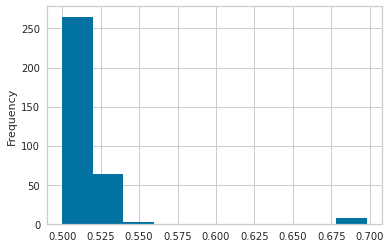

In [20]:
predictions['Score'].plot.hist()

In [21]:
# 결과 평가
(predictions['target']==predictions['Label'].replace({'False':False, 'True':True})).mean()

0.9023668639053254

In [22]:
predictions['Label'].replace({'False':False, 'True':True}).mean()

0.14792899408284024

# End

# 중복데이터를 만들어 예측 성능 비교해 보기 simulation

In [259]:
data = sns.load_dataset('titanic').drop('alive', axis=1)
data.dropna(inplace=True)

In [260]:
from sklearn.model_selection import train_test_split
from sklearn import ensemble 

def prediction(data):
    display(data)
    display(data['survived'].value_counts(normalize=True))
    categorical_list = list(data.select_dtypes(include=['category', 'object']).columns)
    X = pd.get_dummies(data.drop(['survived'], axis=1), prefix= categorical_list) 
    y = data.survived

    X_train, X_test, y_train, y_test=train_test_split(X, y, test_size = 0.2, random_state=12)
    rf = ensemble.RandomForestClassifier(random_state=11)
    y_predict = rf.fit(X_train, y_train).predict(X_test)
    accuracy_score(y_test, y_predict)
    print(classification_report(y_test, y_predict))
    #sns.set_style("whitegrid", {'axes.grid' : False})
    #plot_confusion_matrix(rf, X_test, y_test)

In [261]:
prediction(data)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,True


1    0.675824
0    0.324176
Name: survived, dtype: float64

              precision    recall  f1-score   support

           0       0.58      0.47      0.52        15
           1       0.68      0.77      0.72        22

    accuracy                           0.65        37
   macro avg       0.63      0.62      0.62        37
weighted avg       0.64      0.65      0.64        37



In [225]:
prediction(data.append(data))

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,True


1    0.675824
0    0.324176
Name: survived, dtype: float64

              precision    recall  f1-score   support

           0       0.91      0.91      0.91        22
           1       0.96      0.96      0.96        51

    accuracy                           0.95        73
   macro avg       0.93      0.93      0.93        73
weighted avg       0.95      0.95      0.95        73



In [229]:
false_data = data[data['survived'] == 1].copy()
false_data.loc[:, 'survived'] = 0
prediction(data.append(false_data))

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
862,0,1,female,48.0,0,0,25.9292,S,First,woman,False,D,Southampton,True
871,0,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,False
879,0,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,False
887,0,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,True


0    0.596721
1    0.403279
Name: survived, dtype: float64

              precision    recall  f1-score   support

           0       0.38      0.31      0.34        39
           1       0.07      0.09      0.08        22

    accuracy                           0.23        61
   macro avg       0.22      0.20      0.21        61
weighted avg       0.26      0.23      0.24        61



In [232]:
data = data.append(false_data)
data.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alone'],
      dtype='object')

In [240]:
c = 0
for i, g in data.groupby(['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alone']):
    c += 1
    if c < 3:
        g

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
297,0,1,female,2.0,1,2,151.55,S,First,child,False,C,Southampton,False


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
435,1,1,female,14.0,1,2,120.0,S,First,child,False,B,Southampton,False
435,0,1,female,14.0,1,2,120.0,S,First,child,False,B,Southampton,False
435,0,1,female,14.0,1,2,120.0,S,First,child,False,B,Southampton,False


# Statistical comparison of models using grid search
- https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_stats.html#sphx-glr-auto-examples-model-selection-plot-grid-search-stats-py

Text(0.5, 1.0, 'Data')

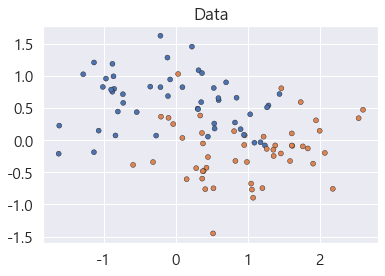

In [34]:
from sklearn.datasets import make_moons
X, y = make_moons(noise=0.352, random_state=1, n_samples=100)

sns.scatterplot(
    x=X[:, 0], y=X[:, 1], hue=y, marker="o", s=25, edgecolor="k", legend=False
).set_title("Data")
plt.show()

In [ ]:
GridSearchCV(estimator=svc, param_grid=param_grid, scoring="pr", cv=cv)

In [58]:
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from sklearn.svm import SVC

param_grid = [
    {"kernel": ["linear"]},
    {"kernel": ["poly"], "degree": [2, 3]},
    {"kernel": ["rbf"]},
]

svc = SVC(random_state=0)

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=0)

search = GridSearchCV(estimator=svc, param_grid=param_grid, scoring="roc_auc", cv=cv) # scoring="average_precision"
search.fit(X, y)

GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=10, n_splits=10, random_state=0),
             estimator=SVC(random_state=0),
             param_grid=[{'kernel': ['linear']},
                         {'degree': [2, 3], 'kernel': ['poly']},
                         {'kernel': ['rbf']}],
             scoring='roc_auc')

In [59]:
results_df = pd.DataFrame(search.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df = results_df.set_index(
    results_df["params"].apply(lambda x: "_".join(str(val) for val in x.values()))
).rename_axis("kernel")
results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

,params,rank_test_score,mean_test_score,std_test_score
kernel,,,,
rbf,{'kernel': 'rbf'},1,0.9400,0.079297
linear,{'kernel': 'linear'},2,0.9300,0.077846
3_poly,"{'degree': 3, 'kernel': 'poly'}",3,0.9044,0.098776
2_poly,"{'degree': 2, 'kernel': 'poly'}",4,0.6852,0.169106


<AxesSubplot:>

Text(0.5, 0, 'CV test fold')

Text(0, 0.5, 'Model AUC')

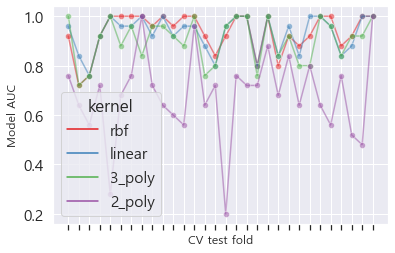

Correlation of models:
 kernel       rbf    linear    3_poly    2_poly
kernel                                        
rbf     1.000000  0.882561  0.783392  0.351390
linear  0.882561  1.000000  0.746492  0.298688
3_poly  0.783392  0.746492  1.000000  0.355440
2_poly  0.351390  0.298688  0.355440  1.000000


In [60]:
# create df of model scores ordered by performance
model_scores = results_df.filter(regex=r"split\d*_test_score")

# plot 30 examples of dependency between cv fold and AUC scores
fig, ax = plt.subplots()
sns.lineplot(
    data=model_scores.transpose().iloc[:30],
    dashes=False,
    palette="Set1",
    marker="o",
    alpha=0.5,
    ax=ax,
)
ax.set_xlabel("CV test fold", size=12, labelpad=10)
ax.set_ylabel("Model AUC", size=12)
ax.tick_params(bottom=True, labelbottom=False)
plt.show()

# print correlation of AUC scores across folds
print(f"Correlation of models:\n {model_scores.transpose().corr()}")

## Comparing two models: frequentist approach
- Let's implement a corrected right-tailed paired t-test to evaluate if the performance of the first model is significantly better than that of the second model. 
- Our null hypothesis is that the second model performs at least as good as the first model.

In [61]:
from scipy.stats import t

def corrected_std(differences, n_train, n_test):
    kr = len(differences)
    corrected_var = np.var(differences, ddof=1) * (1 / kr + n_test / n_train)
    corrected_std = np.sqrt(corrected_var)
    return corrected_std

def compute_corrected_ttest(differences, df, n_train, n_test):
    mean = np.mean(differences)
    std = corrected_std(differences, n_train, n_test)
    t_stat = mean / std
    p_val = t.sf(np.abs(t_stat), df)  # right-tailed t-test
    return t_stat, p_val

In [62]:
model_scores
len(model_scores.iloc[0].values)

,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,...,split90_test_score,split91_test_score,split92_test_score,split93_test_score,split94_test_score,split95_test_score,split96_test_score,split97_test_score,split98_test_score,split99_test_score
kernel,,,,,,,,,,,,,,,,,,,,,
rbf,0.92,0.72,0.76,0.92,1.00,1.00,1.00,1.00,0.96,1.00,...,0.96,0.88,1.00,0.72,0.92,1.00,0.96,1.00,1.00,0.84
linear,0.96,0.84,0.76,0.92,1.00,0.96,0.96,1.00,0.92,1.00,...,0.96,0.92,1.00,0.76,0.92,1.00,0.92,0.92,1.00,0.84
3_poly,1.00,0.72,0.76,0.92,1.00,0.88,0.96,0.84,0.96,0.96,...,0.92,0.92,1.00,0.68,0.96,1.00,0.96,0.92,1.00,0.56
2_poly,0.76,0.64,0.56,0.72,0.28,0.68,0.76,1.00,0.72,0.64,...,0.68,0.60,0.88,0.52,0.48,0.68,0.68,0.76,0.84,0.52


100

In [63]:
model_1_scores = model_scores.iloc[0].values  # scores of the best model
model_2_scores = model_scores.iloc[1].values  # scores of the second-best model

differences = model_1_scores - model_2_scores

n = differences.shape[0]  # number of test sets
df = n - 1
n_train = len(list(cv.split(X, y))[0][0])
n_test = len(list(cv.split(X, y))[0][1])

t_stat, p_val = compute_corrected_ttest(differences, df, n_train, n_test)
print(f"Corrected t-value: {t_stat:.3f}\nCorrected p-value: {p_val:.3f}")

Corrected t-value: 0.750
Corrected p-value: 0.227


In [64]:
t_stat_uncorrected = np.mean(differences) / np.sqrt(np.var(differences, ddof=1) / n)
p_val_uncorrected = t.sf(np.abs(t_stat_uncorrected), df)

print(
    f"Uncorrected t-value: {t_stat_uncorrected:.3f}\n"
    f"Uncorrected p-value: {p_val_uncorrected:.3f}"
)

Uncorrected t-value: 2.611
Uncorrected p-value: 0.005


Using the conventional significance alpha level at p=0.05, we observe that the uncorrected t-test concludes that the first model is significantly better than the second.

With the corrected approach, in contrast, we fail to detect this difference.

In the latter case, however, the frequentist approach does not let us conclude that the first and second model have an equivalent performance. If we wanted to make this assertion we need to use a Bayesian approach

## Comparing two models: Bayesian approach

In [70]:
# initialize random variable
t_post = t(
    df, loc=np.mean(differences), scale=corrected_std(differences, n_train, n_test)
)
t_post.ppf(0.999)

0.05231041089954389

([<matplotlib.axis.XTick at 0x132efab9d00>,
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

Text(0, 0.5, 'Probability density')

Text(0.5, 0, 'Mean difference ($\\mu$)')

Text(0.5, 1.0, 'Posterior distribution')

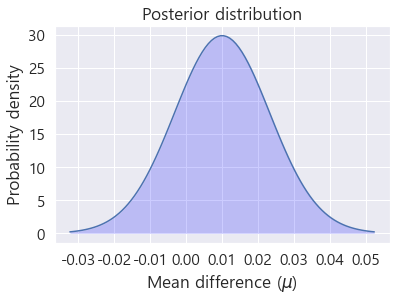

In [71]:
x = np.linspace(t_post.ppf(0.001), t_post.ppf(0.999), 100)

plt.plot(x, t_post.pdf(x))
plt.xticks(np.arange(-0.04, 0.06, 0.01))
plt.fill_between(x, t_post.pdf(x), 0, facecolor="blue", alpha=0.2)
plt.ylabel("Probability density")
plt.xlabel(r"Mean difference ($\mu$)")
plt.title("Posterior distribution")
plt.show()

In [73]:
better_prob = 1 - t_post.cdf(0)

print(
    f"Probability of {model_scores.index[0]} being more accurate than "
    f"{model_scores.index[1]}: {better_prob:.3f}"
)
print(
    f"Probability of {model_scores.index[1]} being more accurate than "
    f"{model_scores.index[0]}: {1 - better_prob:.3f}"
)

Probability of rbf being more accurate than linear: 0.773
Probability of linear being more accurate than rbf: 0.227


### Region of Practical Equivalence

In [74]:
rope_interval = [-0.01, 0.01]
rope_prob = t_post.cdf(rope_interval[1]) - t_post.cdf(rope_interval[0])

print(
    f"Probability of {model_scores.index[0]} and {model_scores.index[1]} "
    f"being practically equivalent: {rope_prob:.3f}"
)

Probability of rbf and linear being practically equivalent: 0.432


([<matplotlib.axis.XTick at 0x132e9593cd0>,
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

Text(0, 0.5, 'Probability density')

Text(0.5, 0, 'Mean difference ($\\mu$)')

Text(0.5, 1.0, 'Posterior distribution under the ROPE')

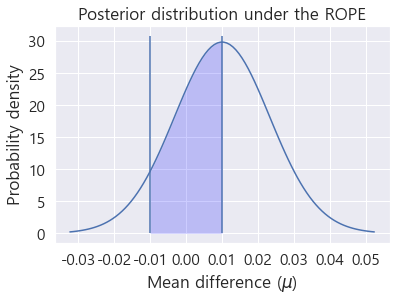

In [75]:
x_rope = np.linspace(rope_interval[0], rope_interval[1], 100)

plt.plot(x, t_post.pdf(x))
plt.xticks(np.arange(-0.04, 0.06, 0.01))
plt.vlines([-0.01, 0.01], ymin=0, ymax=(np.max(t_post.pdf(x)) + 1))
plt.fill_between(x_rope, t_post.pdf(x_rope), 0, facecolor="blue", alpha=0.2)
plt.ylabel("Probability density")
plt.xlabel(r"Mean difference ($\mu$)")
plt.title("Posterior distribution under the ROPE")
plt.show()

In [76]:
cred_intervals = []
intervals = [0.5, 0.75, 0.95]

for interval in intervals:
    cred_interval = list(t_post.interval(interval))
    cred_intervals.append([interval, cred_interval[0], cred_interval[1]])

cred_int_df = pd.DataFrame(
    cred_intervals, columns=["interval", "lower value", "upper value"]
).set_index("interval")
cred_int_df

,lower value,upper value
interval,,
0.50,0.000977,0.019023
0.75,-0.005422,0.025422
0.95,-0.016445,0.036445


## Pairwise comparison of all models: frequentist approach

In [47]:
from itertools import combinations
from math import factorial

n_comparisons = factorial(len(model_scores)) / (
    factorial(2) * factorial(len(model_scores) - 2)
)
pairwise_t_test = []

for model_i, model_k in combinations(range(len(model_scores)), 2):
    model_i_scores = model_scores.iloc[model_i].values
    model_k_scores = model_scores.iloc[model_k].values
    differences = model_i_scores - model_k_scores
    t_stat, p_val = compute_corrected_ttest(differences, df, n_train, n_test)
    p_val *= n_comparisons  # implement Bonferroni correction
    # Bonferroni can output p-values higher than 1
    p_val = 1 if p_val > 1 else p_val
    pairwise_t_test.append(
        [model_scores.index[model_i], model_scores.index[model_k], t_stat, p_val]
    )

pairwise_comp_df = pd.DataFrame(
    pairwise_t_test, columns=["model_1", "model_2", "t_stat", "p_val"]
).round(3)
pairwise_comp_df

,model_1,model_2,t_stat,p_val
0,rbf,linear,0.750,1.000
1,rbf,3_poly,1.657,0.302
2,rbf,2_poly,4.565,0.000
3,linear,3_poly,1.111,0.807
4,linear,2_poly,4.276,0.000
5,3_poly,2_poly,3.851,0.001


## Pairwise comparison of all models: Bayesian approach

In [48]:
pairwise_bayesian = []

for model_i, model_k in combinations(range(len(model_scores)), 2):
    model_i_scores = model_scores.iloc[model_i].values
    model_k_scores = model_scores.iloc[model_k].values
    differences = model_i_scores - model_k_scores
    t_post = t(
        df, loc=np.mean(differences), scale=corrected_std(differences, n_train, n_test)
    )
    worse_prob = t_post.cdf(rope_interval[0])
    better_prob = 1 - t_post.cdf(rope_interval[1])
    rope_prob = t_post.cdf(rope_interval[1]) - t_post.cdf(rope_interval[0])

    pairwise_bayesian.append([worse_prob, better_prob, rope_prob])

pairwise_bayesian_df = pd.DataFrame(
    pairwise_bayesian, columns=["worse_prob", "better_prob", "rope_prob"]
).round(3)

pairwise_comp_df = pairwise_comp_df.join(pairwise_bayesian_df)
pairwise_comp_df

,model_1,model_2,t_stat,p_val,worse_prob,better_prob,rope_prob
0,rbf,linear,0.750,1.000,0.068,0.500,0.432
1,rbf,3_poly,1.657,0.302,0.018,0.882,0.100
2,rbf,2_poly,4.565,0.000,0.000,1.000,0.000
3,linear,3_poly,1.111,0.807,0.063,0.750,0.187
4,linear,2_poly,4.276,0.000,0.000,1.000,0.000
5,3_poly,2_poly,3.851,0.001,0.000,1.000,0.000
